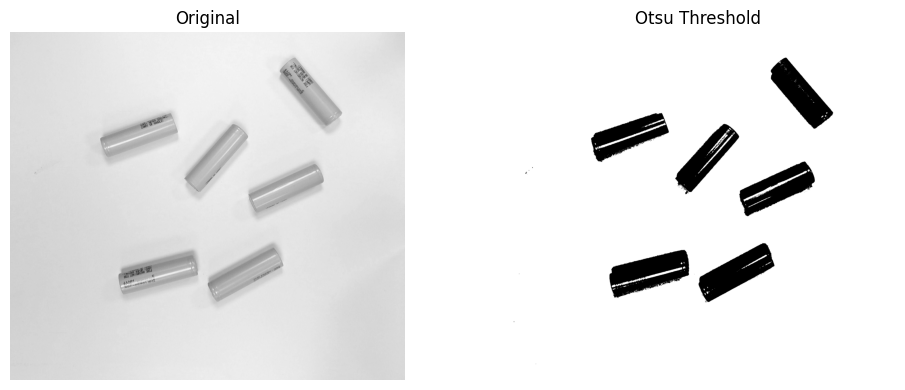

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def threshold_image(input_path):
    img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)  # Fix 2: use input_path
    if img is None:
        raise ValueError(f"Could not read image from: {input_path}")
    T_otsu, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return img, th_otsu  # return original too for comparison

# Fix 1: actually call the function and capture return values
img, th_otsu = threshold_image("image.png")

# Fix 3: fill both subplots
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(th_otsu, cmap='gray')
plt.title('Otsu Threshold')
plt.axis('off')

plt.tight_layout()
plt.show()



In [6]:
threshold_image("image.png")

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1993, 2261), dtype=uint8)

In [ ]:
import cv2
import numpy as np

def segment_image(input_path):
    img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image from: {input_path}")
    # Thresholding
    T_otsu, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Morphology
    kernel = np.ones((7, 7), np.uint8)
    opening = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, kernel, iterations=3)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=1)
    return closing
img , th_otsu = segment_image("image.png")

# Fix 3: fill both subplots
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(th_otsu, cmap='gray')
plt.title('Original')
plt.axis('off')


ValueError: too many values to unpack (expected 2)